In [9]:
import pandas as pd
import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay



In [10]:
os.makedirs('../models', exist_ok=True)
# Lista de tus datasets
datasets = ['adults', 'combined', 'toddlers']

data_dict = {}

for name in datasets:
    # Cargar datos
    X_train = pd.read_csv(f'../data/processed/{name}_train.csv')
    X_test = pd.read_csv(f'../data/processed/{name}_test.csv')
    
    # Si tus archivos train/test ya contienen la variable target, 
    # recuerda separarla (ej: y_train = X_train.pop('target_column'))
    
    data_dict[name] = {'train': X_train, 'test': X_test}

In [11]:
RANDOM_STATE = 42
MODEL_SPACE = {
    "Baseline": {
        "estimator": DummyClassifier(strategy="most_frequent"),
        "param_grid": {}
    },
    "Regresion Logistica": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "C": [0.01, 0.1, 1, 10],
            #"penalty": ["l2"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            # XGBoost no tiene class_weight; se usa scale_pos_weight para
            # compensar el desbalance. Se calcula por dataset mas abajo.
        }
    }
}


In [12]:

# Configuración de validación cruzada

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



all_results = []
# Bucle de entrenamiento
for name, data in data_dict.items():
    print(f"--- Entrenando para dataset: {name} ---")

    # Aquí accedes a la parte 'train' de tu diccionario
    df_train = data['train'] 

    
    
    # Suponiendo que el target es la última columna o tiene un nombre específico
    # Si el target NO está separado, sepáralo aquí:
    y_train = df_train.pop('target').astype(int) # Asegúrate de que 'target' es el nombre real
    X_train = df_train

    # Calcular scale_pos_weight dinámicamente para XGBoost si hay desbalance
    ratio = (len(y_train) - y_train.sum()) / y_train.sum()
    
    for model_name, config in MODEL_SPACE.items():
        
        clf = config['estimator']
        params = config['param_grid']
        
        # Ajuste especial para XGBoost si es necesario
        if model_name == "XGBoost":
            clf.set_params(scale_pos_weight=ratio)
        # 1. GridSearch
        grid = GridSearchCV(clf, params, cv=cv, scoring='f1')
        grid.fit(X_train, y_train)

        y_pred = grid.best_estimator_.predict(data['test'].drop('target', axis=1))
        y_test = data['test']['target']

        print(f"Resultados para {name} - {model_name}:")
        print(classification_report(y_test, y_pred, zero_division=0))
        print("Matriz de Confusión:")
        print(confusion_matrix(y_test, y_pred))
        
        # Modifica tu bloque de append así:
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # Capturamos las métricas específicas de la clase '1' (TEA)
        # y las métricas globales
        all_results.append({
            'Dataset': name,
            'Modelo': model_name,
            'F1-Score (TEA)': report['1']['f1-score'],
            'Recall (TEA)': report['1']['recall'],
            'Precision (TEA)': report['1']['precision'],
            'Accuracy Global': report['accuracy'],
            'Support (TEA)': report['1']['support']
        })

        # 2. Guardar el mejor modelo
        model_filename = f'../models/{name}_{model_name}.pkl'
        with open(model_filename, 'wb') as f:
            pickle.dump(grid.best_estimator_, f)
            
        print(f"Modelo {model_name} guardado en {model_filename}")

--- Entrenando para dataset: adults ---
Resultados para adults - Baseline:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       103
           1       0.00      0.00      0.00        38

    accuracy                           0.73       141
   macro avg       0.37      0.50      0.42       141
weighted avg       0.53      0.73      0.62       141

Matriz de Confusión:
[[103   0]
 [ 38   0]]
Modelo Baseline guardado en ../models/adults_Baseline.pkl
Resultados para adults - Regresion Logistica:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       103
           1       1.00      0.97      0.99        38

    accuracy                           0.99       141
   macro avg       1.00      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141

Matriz de Confusión:
[[103   0]
 [  1  37]]
Modelo Regresion Logistica guardado en ../models/adults_Regresion Logistica.pkl

In [13]:
df_resumen = pd.DataFrame(all_results)
df_resumen

,Dataset,Modelo,F1-Score (TEA),Recall (TEA),Precision (TEA),Accuracy Global,Support (TEA)
0,adults,Baseline,0.000000,0.000000,0.000000,0.730496,38.0
1,adults,Regresion Logistica,0.986667,0.973684,1.000000,0.992908,38.0
2,adults,Random Forest,0.880000,0.868421,0.891892,0.936170,38.0
3,adults,XGBoost,0.986667,0.973684,1.000000,0.992908,38.0
4,combined,Baseline,0.000000,0.000000,0.000000,0.702881,361.0
5,combined,Regresion Logistica,0.854592,0.927978,0.791962,0.906173,361.0
6,combined,Random Forest,0.967742,0.955679,0.980114,0.981070,361.0
7,combined,XGBoost,1.000000,1.000000,1.000000,1.000000,361.0
8,toddlers,Baseline,0.817927,1.000000,0.691943,0.691943,146.0
9,toddlers,Regresion Logistica,1.000000,1.000000,1.000000,1.000000,146.0


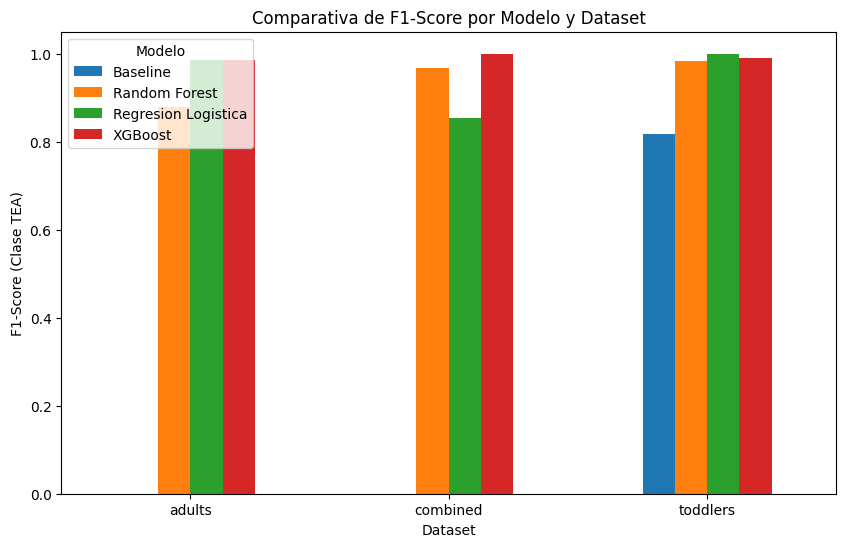

In [14]:

import matplotlib.pyplot as plt

# Esto hará que el desempeño de los modelos sea evidente a simple vista
df_resumen = pd.DataFrame(all_results)
df_resumen.pivot(index='Dataset', columns='Modelo', values='F1-Score (TEA)').plot(kind='bar', figsize=(10, 6))
plt.title("Comparativa de F1-Score por Modelo y Dataset")
plt.ylabel("F1-Score (Clase TEA)")
plt.xticks(rotation=0)
plt.show()

In [15]:
import pickle  # Asegúrate de importar pickle

# Cargar el modelo guardado con pickle
model_path = '../models/adults_XGBoost.pkl'
with open(model_path, 'rb') as f:
    modelo_cargado = pickle.load(f)

# 1. Obtenemos el DataFrame de test
df_test = data_dict["adults"]["test"].copy()

# 2. Eliminamos el target para que coincida con las columnas del entrenamiento
if 'target' in df_test.columns:
    df_test = df_test.drop(columns=['target'])

# 3. Ahora sí, hacemos la predicción
# Si el error persiste, significa que necesitas el preprocesador para 
# ajustar las variables a las 99 esperadas.
prediccion = modelo_cargado.predict(df_test.iloc[0:1])

# Suponiendo que ya tienes la predicción (del paso anterior)
valor_real = data_dict["adults"]["test"].iloc[0:1]["target"].values[0]

print(f"Predicción del modelo: {prediccion[0]}")
print(f"Valor real (etiqueta): {valor_real}")

if prediccion[0] == valor_real:
    print("¡El modelo ha acertado!")
else:
    print("El modelo ha fallado en esta instancia.")


Predicción del modelo: 0
Valor real (etiqueta): 0
¡El modelo ha acertado!
